# Compare the Sr88 MQDT models

rydstate provides two sets of MQDT models for $^{88}$Sr:

- the default models (`get_mqdt("Sr88")`) are the eigenchannel models of
  [F. Robicheaux, J. Phys. B 52, 244001 (2019)](https://doi.org/10.1088/1361-6455/ab4c22).
  They only contain the 5s$nl$ channels and are valid for high effective principal quantum numbers.
- the models with the tag `vaillant2024` (`get_mqdt("Sr88", "vaillant2024")`) are the K-matrix models of
  [C. L. Vaillant, M. P. A. Jones and R. M. Potvliege, J. Phys. B 47, 155001 (2014)](https://doi.org/10.1088/0953-4075/47/15/155001)
  with the corrected parameters of their [Addendum, J. Phys. B 57, 199401 (2024)](https://doi.org/10.1088/1361-6455/ad76f0).
  They include the doubly excited 4d$nl$ and 5p$n$p perturber channels explicitly and are therefore valid down to the
  lowest 5s$nl$ states. The only series they do not cover are the 5s$n$f $^3F_J$ series, which are described
  by single channel models with the Rydberg-Ritz quantum defects of
  [J. P. Connerade et al., J. Phys. B 25, 1405 (1992)](https://doi.org/10.1088/0953-4075/25/7/012) instead.

This notebook compares the MQDT states of both model sets for several series:
their quantum defects (together with the NIST energy levels shipped with rydstate),
the energy differences of the states in the common range of validity,
the singlet-triplet mixing of the 5s$n$d $J=2$ states and the perturber states, which only the new models contain.


In [1]:
from __future__ import annotations

# Uncomment the next line if you have ipympl installed and want interactive plots
# %matplotlib widget
import logging
from typing import TYPE_CHECKING

import matplotlib.pyplot as plt
import numpy as np

from rydstate import BasisMQDT
from rydstate.species import get_mqdt, get_sqdt
from rydstate.species.utils import calc_nu_from_energy

if TYPE_CHECKING:
    from rydstate.rydberg_state import RydbergKet

logging.getLogger("rydstate").setLevel(logging.ERROR)  # the radial wavefunctions of the closed perturber channels warn

CM_TO_MHZ = 29979.2458

## Build the bases

We compute all MQDT states with $l_r \le 3$ for $2.5 \le \nu \le 40$ with both model sets.
The default models start at $\nu \approx 5$ to $25$ depending on the series, the Vaillant models at $\nu \approx 3$ to $10$.

In [2]:
nu_range = (2.5, 40)
bases = {
    "Robicheaux 2019": BasisMQDT("Sr88", nu=nu_range, l_r=(0, 3), mqdt=None),
    "Vaillant 2024": BasisMQDT("Sr88", nu=nu_range, l_r=(0, 3), mqdt="vaillant2024"),
}
styles = {"Robicheaux 2019": {"color": "C1", "marker": "s"}, "Vaillant 2024": {"color": "C0", "marker": "o"}}

# Both model sets use the same 5s ionization threshold (45932.2002 1/cm, Couturier et al. 2019), so the effective
# principal quantum numbers nu (and the quantum defects) of their states are directly comparable.
thresholds = {
    key: basis.mqdt.get_ionization_threshold(basis.mqdt.get_core_kets()[0], "1/cm") for key, basis in bases.items()
}
assert len({round(value, 6) for value in thresholds.values()}) == 1, thresholds
print(f"5s ionization threshold: {thresholds['Vaillant 2024']:.4f} 1/cm")

for key, basis in bases.items():
    print(f"{key}: {len(basis.states)} states from {len(basis.models)} models")
    for model in basis.models:
        if len(model.outer_channels) > 1 or model.nu_min < 10:  # skip the trivial single channel fallback models
            print(f"    {model.name:40s} {len(model.outer_channels)} channels")

5s ionization threshold: 45932.2002 1/cm
Robicheaux 2019: 389 states from 12 models
    P J=0, nu > 7                            1 channels
    P J=1 (recombination), 1.8 < nu < 2.2    2 channels
    P J=1, nu > 5                            2 channels
    P J=2, nu > 5                            1 channels
    D J=2, nu > 25                           2 channels
    F J=2, nu > 9                            1 channels
    F J=3, nu > 9                            2 channels
    F J=4, nu > 9                            1 channels
Vaillant 2024: 497 states from 13 models
    S J=0, nu > 3.7                          3 channels
    S J=1, nu > 3.4                          2 channels
    P J=0, nu > 2.8                          2 channels
    P J=1 singlet, nu > 2.8                  2 channels
    P J=1 triplet, nu > 2.8                  2 channels
    P J=2, nu > 2.8                          2 channels
    D J=1, nu > 9.5                          2 channels
    D J=2, nu > 5.7                

## Select the Rydberg series

A series is selected by the symmetry of its states ($F$, parity), the dominant orbital angular momentum $l_r$ and the
spin character (singlet or triplet). States dominated by a perturber channel ($\langle l_c \rangle > 1/2$) are excluded here
and shown separately below.

In [3]:
series = {
    # label: (l_r, f_tot, parity, s_tot range)
    "5sns 1S0": (0, 0, +1, (0, 0.5)),
    "5sns 3S1": (0, 1, +1, (0.5, 1)),
    "5snp 1P1": (1, 1, -1, (0, 0.5)),
    "5snp 3P2": (1, 2, -1, (0.5, 1)),
    "5snd 1D2": (2, 2, +1, (0, 0.5)),
    "5snd 3D2": (2, 2, +1, (0.5, 1)),
    "5snd 3D1": (2, 1, +1, (0.5, 1)),
    "5snd 3D3": (2, 3, +1, (0.5, 1)),
    "5snf 1F3": (3, 3, -1, (0, 0.5)),
}


def select_series(basis: BasisMQDT, l_r: int, f_tot: float, parity: int, s_tot: tuple[float, float]) -> BasisMQDT:
    return (
        basis.shallow_copy()
        .filter_states("f_tot", f_tot)
        .filter_states("parity", parity)
        .filter_states("l_c", (0, 0.5))
        .filter_states("l_r", (l_r - 0.5, l_r + 0.5))
        .filter_states("s_tot", s_tot)
        .sort_states("nu")
    )


series_bases = {
    key: {label: select_series(basis, *args) for label, args in series.items()} for key, basis in bases.items()
}

for label in series:
    print(f"{label}: " + ", ".join(f"{key}: {len(series_bases[key][label])} states" for key in bases))

5sns 1S0: Robicheaux 2019: 30 states, Vaillant 2024: 36 states
5sns 3S1: Robicheaux 2019: 29 states, Vaillant 2024: 37 states
5snp 1P1: Robicheaux 2019: 35 states, Vaillant 2024: 38 states
5snp 3P2: Robicheaux 2019: 35 states, Vaillant 2024: 37 states
5snd 1D2: Robicheaux 2019: 15 states, Vaillant 2024: 35 states
5snd 3D2: Robicheaux 2019: 15 states, Vaillant 2024: 35 states
5snd 3D1: Robicheaux 2019: 23 states, Vaillant 2024: 31 states
5snd 3D3: Robicheaux 2019: 15 states, Vaillant 2024: 37 states
5snf 1F3: Robicheaux 2019: 31 states, Vaillant 2024: 36 states


## Quantum defects

We plot the fractional part of the quantum defect, $\delta \bmod 1 = (-\nu) \bmod 1$, against $\nu$.
Using the fractional part avoids having to assign principal quantum numbers $n$, which are ambiguous close to the
perturbers, where the quantum defect changes by almost one within a few states (e.g. in the 5s$n$d triplet series).
The black crosses are the NIST energy levels shipped with rydstate (available up to $n = 20$),
converted to $\nu$ with the common 5s ionization threshold of both model sets.

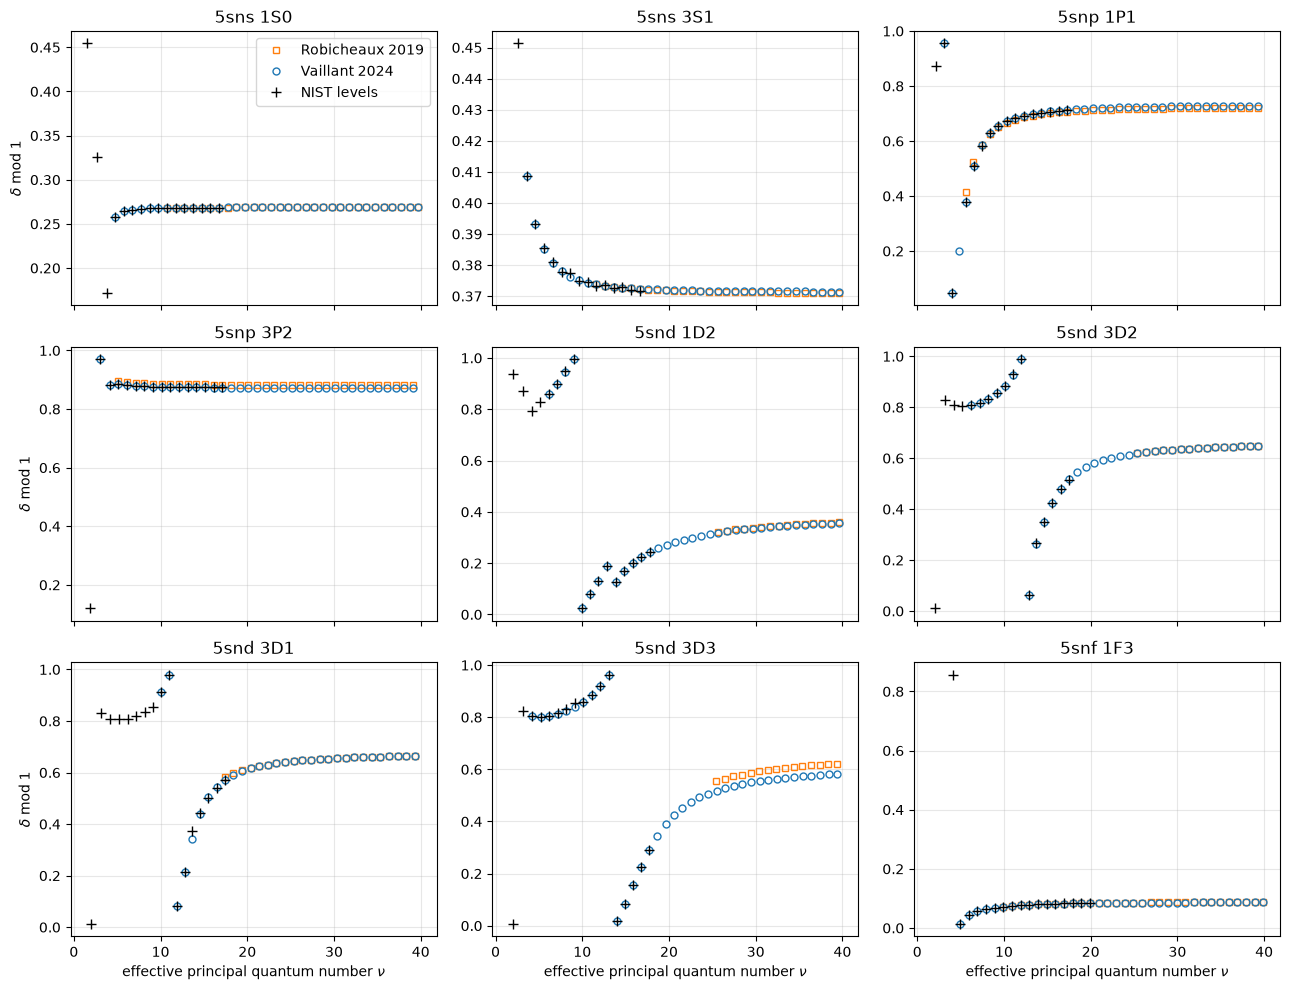

In [4]:
sqdt = get_sqdt("Sr88")
threshold_au = get_mqdt("Sr88").reference_ionization_threshold_au  # identical for both model sets, see above
reduced_mass_au = sqdt.element_properties.reduced_mass_au


def nist_nus(l_r: int, j_tot: float, s_tot: float) -> np.ndarray:
    energies_au = [
        energy_au
        for (_n, l, j, s), energy_au in sqdt._nist_energy_levels.items()  # noqa: SLF001
        if (l, j, s) == (l_r, j_tot, s_tot)
    ]
    return np.array([calc_nu_from_energy(reduced_mass_au, e - threshold_au) for e in energies_au])


def fractional_quantum_defect(nus: np.ndarray) -> np.ndarray:
    return (-np.asarray(nus)) % 1


fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True)
for ax, (label, (l_r, f_tot, _parity, s_tot)) in zip(axes.flat, series.items(), strict=True):
    for key, basis in series_bases.items():
        nus = basis[label].calc_exp_qn("nu")
        ax.plot(nus, fractional_quantum_defect(nus), ls="none", ms=5, mfc="none", label=key, **styles[key])
    nus = nist_nus(l_r, f_tot, 0 if s_tot[1] <= 0.5 else 1)
    ax.plot(nus, fractional_quantum_defect(nus), "k+", ms=7, label="NIST levels")
    ax.set_title(label)
    ax.grid(alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel(r"effective principal quantum number $\nu$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\delta \; \mathrm{mod} \; 1$")
axes[0, 0].legend()
fig.tight_layout()
plt.show()

The Vaillant models follow the NIST levels down to the lowest states of each series and reproduce the perturber
signatures in the D series (the quantum defect of the 5s$n$d triplet series changes by almost one around
$\nu \approx 12$ to $18$ because of the 4d6s perturber). In the common range of validity both model sets agree closely,
with visible differences in the asymptotic quantum defects of the 5s$n$p $^3$P$_2$ and 5s$n$d $^3$D$_3$ series,
which the Vaillant models only fit up to $n = 15$ and $n = 29$, respectively.

## Energy differences in the common range of validity

For every state of the Vaillant models above the lowest state of the corresponding Robicheaux model we take the
closest Robicheaux state (in energy) of the same series and plot the energy difference.
Since both model sets use the same ionization threshold, these differences reflect only the different quantum defects
(a threshold difference $\Delta I$ would shift all energies of a model set rigidly by $\Delta I$, without changing $\nu$).
For the 5s$n$s $^1$S$_0$ series, the two models agree to better than 35 MHz for $\nu > 20$
(below 10 MHz at $\nu \approx 40$).

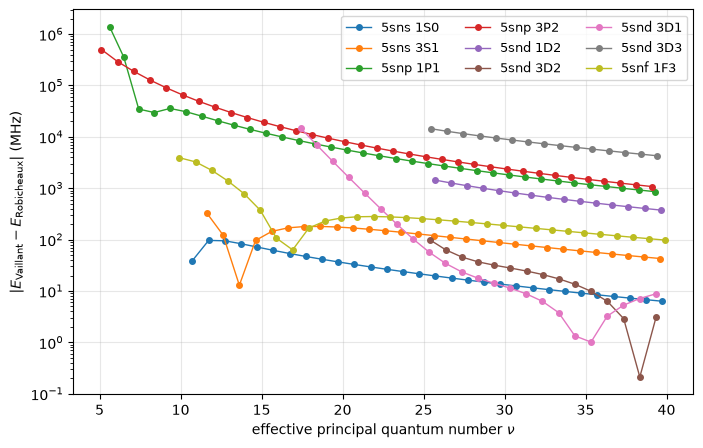

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for i, label in enumerate(series):
    old = series_bases["Robicheaux 2019"][label]
    new = series_bases["Vaillant 2024"][label]
    if len(old) == 0 or len(new) == 0:
        continue
    old_energies = np.array([state.get_energy("1/cm") for state in old.states])
    nus, diffs = [], []
    for state in new.states:
        if state.nu < old.states[0].nu - 0.4:
            continue
        energy = state.get_energy("1/cm")
        idx = np.argmin(np.abs(old_energies - energy))
        nus.append(state.nu)
        diffs.append(abs(energy - old_energies[idx]) * CM_TO_MHZ)
    ax.plot(nus, diffs, marker="o", ms=4, lw=1, color=f"C{i}", label=label)
ax.set_yscale("log")
ax.set_xlabel(r"effective principal quantum number $\nu$")
ax.set_ylabel(r"$|E_\mathrm{Vaillant} - E_\mathrm{Robicheaux}|$ (MHz)")
ax.grid(alpha=0.3)
ax.legend(ncol=3, fontsize=9)
plt.show()

## Singlet-triplet mixing of the 5s$n$d $J=2$ states

The 5s$n$d $^1$D$_2$ and $^3$D$_2$ series are strongly mixed. The six channel Vaillant model describes the
mixing including its resonant enhancement around the 4d$^2$ $^3$P$_2$ perturber ($\nu \approx 9.5$, i.e. in the
5s15d states), whereas the Robicheaux model uses a constant mixing angle and is only valid for $\nu > 25$.
The triplet fraction is the expectation value of the total spin $\langle S \rangle$ of the state.

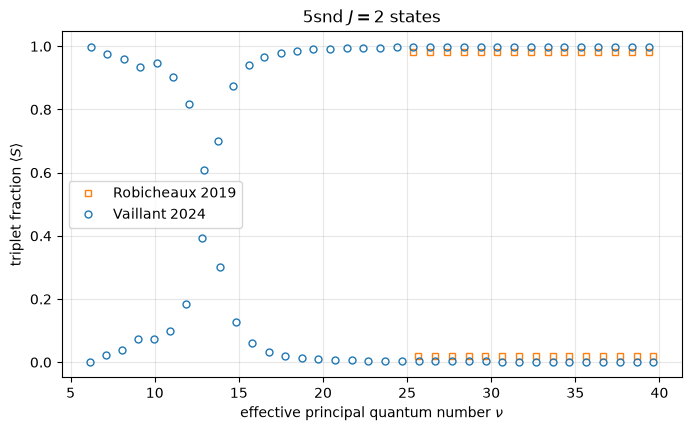

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for key, basis in bases.items():
    d2 = (
        basis.shallow_copy()
        .filter_states("f_tot", 2)
        .filter_states("parity", +1)
        .filter_states("l_c", (0, 0.5))
        .filter_states("l_r", (1.5, 2.5))
        .sort_states("nu")
    )
    ax.plot(d2.calc_exp_qn("nu"), d2.calc_exp_qn("s_tot"), ls="none", ms=5, mfc="none", label=key, **styles[key])
ax.set_xlabel(r"effective principal quantum number $\nu$")
ax.set_ylabel(r"triplet fraction $\langle S \rangle$")
ax.set_title(r"5snd $J=2$ states")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## Perturber states

The Vaillant models contain the doubly excited perturber channels explicitly, so they also yield the perturber states
themselves, i.e. the states dominated by a channel with an excited core ($\langle l_c \rangle > 1/2$).
The Robicheaux models do not contain such states.

In [7]:
perturbers = bases["Vaillant 2024"].shallow_copy().filter_states("l_c", (0.5, 3)).sort_states("nu")

print(f"{'energy (1/cm)':>14s} {'nu':>7s} {'F':>3s} {'parity':>6s} {'<l_c>':>6s} {'<S>':>5s}  model")
for state in perturbers.states:
    print(
        f"{state.get_energy('1/cm'):14.3f} {state.nu:7.3f} {state.f_tot:3.0f} {state.parity:6d} "
        f"{state.calc_exp_qn('l_c'):6.2f} {state.calc_exp_qn('s_tot'):5.2f}  {state.model.name}"
    )

 energy (1/cm)      nu   F parity  <l_c>   <S>  model
     37292.073   3.564   0     -1   1.73  1.00  P J=0, nu > 2.8
     37302.730   3.566   1     -1   1.72  1.00  P J=1 triplet, nu > 2.8
     37336.590   3.573   2     -1   1.74  1.00  P J=2, nu > 2.8
     38007.742   3.721   3     -1   0.87  0.00  F J=3 singlet, nu > 3.5
     38444.013   3.828   0      1   0.74  0.15  S J=0, nu > 3.7
     39539.013   4.143   3     -1   0.75  0.00  F J=3 singlet, nu > 3.5
     44525.838   8.833   0      1   1.97  0.59  S J=0, nu > 3.7
     44730.547   9.556   2      1   1.89  0.97  D J=2, nu > 5.7


These are the 4d5p $^3$P$_{0,1,2}$ states at $\nu \approx 3.57$, the 4d5p $^1$F$_3$ state at $\nu \approx 3.72$,
the 4d$^2$ $^3$P$_0$ state at $\nu \approx 8.83$ and the 4d$^2$ $^3$P$_2$ state at $\nu \approx 9.56$
(the 5s7s $^1$S$_0$ state at $\nu \approx 3.83$ also appears here, since the model gives it a predominant 4d$n$d character).
Note that the radial wavefunctions of the closed perturber channels have channel quantum numbers $\nu_i \lesssim l_r + 1$,
for which rydstate warns about the inner boundary of the Numerov integration; the energies are not affected,
but matrix elements involving these components should be treated with care.

## Composition of a single state

Finally we look at the channel composition of one state in both model sets, the 5s30d $^1$D$_2$ state at
$\nu \approx 27.67$. The bars show the squared coefficients of the state on the FJ coupled channels.

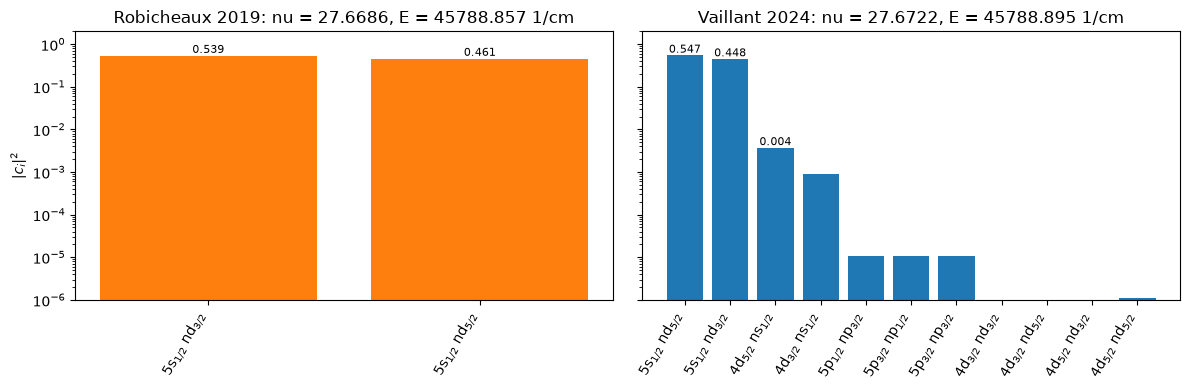

In [8]:
def ket_label(ket: RydbergKet) -> str:
    a = ket.angular
    return f"{a.n_c}{'spdf'[a.l_c]}$_{{{int(2 * a.j_c)}/2}}$ n{'spdf'[a.l_r]}$_{{{int(2 * a.j_r)}/2}}$"


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, key in zip(axes, bases, strict=True):
    d2 = series_bases[key]["5snd 1D2"]
    state = min(d2.states, key=lambda s: abs(s.nu - 27.67))
    weights = np.abs(state.coefficients) ** 2
    labels = [ket_label(ket) for ket in state.rydberg_kets]
    ax.bar(range(len(weights)), weights, color=styles[key]["color"])
    ax.set_xticks(range(len(weights)), labels, rotation=60, ha="right")
    ax.set_title(f"{key}: nu = {state.nu:.4f}, E = {state.get_energy('1/cm'):.3f} 1/cm")
    for x, w in enumerate(weights):
        if w > 1e-3:
            ax.text(x, w, f"{w:.3f}", ha="center", va="bottom", fontsize=8)
axes[0].set_ylabel(r"$|c_i|^2$")
axes[0].set_yscale("log")
axes[0].set_ylim(1e-6, 2)
fig.tight_layout()
plt.show()

Both models describe the state as a superposition of the two 5s$_{1/2}$nd$_j$ channels with a small admixture of the
other channel, but they differ in the size of the singlet-triplet mixing (0.3% vs 1.9% triplet admixture at $n = 30$,
see the previous plot), which is why the weights of the two 5s$_{1/2}$nd$_j$ channels differ noticeably (a pure $^1$D$_2$
state would have weights 3/5 and 2/5). The Vaillant model additionally resolves the small 4d$n$s, 5p$n$p and 4d$n$d
perturber admixtures.